# Astrometric weak-lensing sensitivity: galaxy lens and cluster lens

Forecasts for *Discovering Substellar Dark Matter Halos with Astrometric Weak
Lensing of Multiply Imaged Quasars* (Van Tilburg & Kaplan).

This notebook computes the astrometric response of a macro-image to a population
of dark microhalos and the resulting survey sensitivity, for **both** benchmark
systems:

| Part | System | Lens | Figures produced |
|---|---|---|---|
| I | B1422+231 | galaxy, $z_\mathrm{L}=0.34$, $\sigma_{\delta\theta}=0.1\,\mu$as (EPIC) | `figs/CtildeA.pdf`, `figs/acc.pdf`, `figs/SNR.pdf` |
| II | SDSS J1029+2623 | cluster, $z_\mathrm{L}=0.588$, $\sigma_{\delta\theta}=1\,\mu$as | `figs/CtildeC-J1029.pdf`, `figs/acc-J1029.pdf` |

The two parts share the same machinery (`sensitivity_functions.py`,
`macro_lens_functions.py`); they differ only in the macro-lens model, the
kinematics, the stellar background and the assumed astrometric precision.

**Run order.** Execute the cells top to bottom. Part I needs
`macro_lens_results.npz`, written by `macro_lens.ipynb`. Part II begins with
`from params_J1029_2623 import *`, which deliberately rebinds the system-level
names (`d_lens`, `kappa_fit`, `inv_jacobian_fit`, `labels`, ...) from the galaxy
lens to the cluster lens; Part I must therefore be run *before* Part II, and
re-running a Part I cell afterwards requires re-running Part I from the top.

**Notation** follows the paper throughout: $M_\mathrm{L}$, $r_\mathrm{L}$,
$\rho_s$, $\gamma_\mathrm{L} = r_\mathrm{L}/D_\mathrm{L}$, $\kappa_\mathrm{L}$,
$\theta_{\mathrm{E,L}}$ and $f_\mathrm{sub}$ for the microhalo population;
$\tau$, `N_obs` and $\sigma_{\delta\theta}$ for the campaign; `C_ij`/`C_pq` for
$\widetilde{C}^\mathrm{I}_{pq}$ before/after contraction with $B^\mathrm{I}$
(`inv_jacobian_fit`); `smear_F1`/`smear_F2` for $\mathcal{F}_{1,2}$. Distances use
the `macro_lens_functions` convention (lowercase `d_*` are the paper's
angular-diameter $D_\mathrm{L}, D_\mathrm{S}, D_\mathrm{LS}$; uppercase `D_*` are
comoving). All quoted SNRs are *variance* ratios $S/N$, not Gaussian
significances.

**Physics conventions** (both parts):

- Halo profile: Gaussian-cutoff $1/r$ cusp, $M_\mathrm{L} = 4\pi\sqrt{e}\,\rho_s r_\mathrm{L}^3$,
  form factor $F(k\gamma_\mathrm{L}) = e^{-(k\gamma_\mathrm{L})^2/2}$ (`C_ij_integral`).
- Sweep rate: $\mathrm{d}\big(\theta^\mathrm{I}-\theta_\mathrm{L}\big)/\mathrm{d}t = B^\mathrm{I}\mu - \mu_\mathrm{L}$.
  Only the *bulk* motion is magnified by $B^\mathrm{I}$; a halo's own orbital motion
  moves the deflector, not the image, and enters unmagnified.
- The stochastic power spectral density $\widetilde{C}^\mathrm{I}_{pq}(\omega)$ is
  Eq. (C) of the paper; the differential acceleration covariance
  $\langle\delta\ddot\theta_{0,p}^\mathrm{I,I'}\delta\ddot\theta_{0,q}^\mathrm{I,I'}\rangle$
  is the smeared $\omega^4$ moment of it (Eq. observable_2).


# Setup

## Packages

In [1]:
from preamble import *
from natural_units_GeV import *
from macro_lens_functions import *
from sensitivity_functions import *
from astropy.cosmology import FlatLambdaCDM
cosmo = FlatLambdaCDM(H0=70, Om0=0.3)

# import the lens model class 
from lenstronomy.LensModel.lens_model import LensModel
from lenstronomy.LensModel.lens_model_extensions import LensModelExtensions
# import the lens equation solver class (finding image plane positions of a source position)
from lenstronomy.LensModel.Solver.lens_equation_solver import LensEquationSolver
# import lens model solver with 4 image positions constraints
from lenstronomy.LensModel.Solver.solver4point import Solver4Point
from lenstronomy.Util import util

# Part I --- Galaxy lens: B1422+231

Quadruply-imaged quasar at $z_\mathrm{S} = 3.62$ behind a galaxy at
$z_\mathrm{L} = 0.34$, observed with the fiducial EPIC campaign
($\tau = 10\,$yr, $N = 300$, $\sigma_{\delta\theta} = 0.1\,\mu$as).
Produces `figs/CtildeA.pdf`, `figs/acc.pdf` and `figs/SNR.pdf`.

## Parameters

In [2]:
from params_B1422_231 import *

# The observer and source terms of Eq. (mu) are folded into an effective lens-frame
# velocity (Sec. III B), so only v_lens is nonzero here.
v_obs = np.asarray([0,0]) * km / second
v_lens = v_lens_fid  # bulk fiducial |v_L| ~ 865 km/s, i.e. [612, 612] km/s
v_source = np.asarray([0,0]) * km / second

vec_mu_source = mu_rel(v_obs, v_lens, v_source, z_lens, z_source, d_lens, d_source, d_lens_source)

# fiducial EPIC campaign: baseline tau, N_obs equally spaced epochs, per-epoch relative
# light-centroiding precision sigma_delta_theta
tau = 10 * year
sigma_delta_theta = 0.1 * muas
N_obs = 300

# measurement noise on the fitted proper motion and acceleration, sigma_theta_dot and
# sigma_theta_ddot of App. Proper Motion & Acceleration Estimators; the square of the
# latter is Eq. (noise_2)
sigma_theta_dot = 2*np.sqrt(3) * sigma_delta_theta / np.sqrt(N_obs * tau**2)
sigma_theta_ddot = 12*np.sqrt(5) * sigma_delta_theta / np.sqrt(N_obs * tau**4)

print('sigma_theta_dot = %.2g muas/yr' % (sigma_theta_dot/muasy))
print('sigma_theta_ddot = %.2g muas/yr^2' % (sigma_theta_ddot/muasyy))

theta: 
 [[ 0.386   0.3169]
 [ 0.      0.    ]
 [-0.336  -0.7516]
 [ 0.947  -0.8012]]
theta_500 =  0.040 muas = 0.195e-12 rad
theta_E_star =  1.400 muas
sigma_SIS = 183 km/s, R_200^G = 310 kpc, M_200^G = 4.8e+12 M_Solar
x_sub (projected / LOS-weighted median): A 0.016/0.031, B 0.015/0.030, C 0.017/0.033, D 0.004/0.013
sigma_theta_dot = 0.002 muas/yr
sigma_theta_ddot = 0.0015 muas/yr^2


## Inputs from macro-lens model

In [3]:
filename = 'macro_lens_results.npz'
results = np.load(filename)

kappa_fit = results['kappa_fit']
gamma1_fit = results['gamma1_fit']
gamma2_fit = results['gamma2_fit']
mag_fit = results['mag_fit']
hessian_fit = results['hessian_fit']
jacobian_fit = results['jacobian_fit']
inv_jacobian_fit = results['inv_jacobian_fit']
eigvals_fit = results['eigvals_fit']
eigvecs_fit = results['eigvecs_fit']

In [4]:
f_sub = 0.5        # fraction of the convergence in substructure, kappa_L = f_sub kappa^I
kappa_star = 0.05  # stellar convergence at image A (Tab. tab:macro gives 0.049)

In [5]:
kappa_L = kappa_fit * f_sub # substructure convergence kappa_L^I at the image locations

vec_mu_tilde = np.tensordot(inv_jacobian_fit, vec_mu_source, axes=1) # mu_tilde^I = B^I mu (bulk)
# Sweep rate of image I across a subhalo's deflection field, d/dt[theta^I - theta_L] =
# B^I mu - mu_L: only the bulk term is magnified, the subhalos' own orbital motion mu_L
# enters unmagnified (footnote to Sec. II C; see params_B1422_231).
mu_tilde = np.sqrt(np.linalg.norm(vec_mu_tilde, axis=1)**2 + mu_L_int**2)

# zeta^I: position angle of mu_tilde^I, measured from the RA direction
zeta = np.arctan2(vec_mu_tilde[:,1], vec_mu_tilde[:,0])

print('kappa_L =', kappa_L)
print('mu_tilde =', mu_tilde / muasy, 'muas/yr')
print('zeta =', zeta / degree, 'degree')

kappa_L = [0.1923961  0.23139261 0.18346408 0.8574958 ]
mu_tilde = [0.98730052 1.38416149 0.5039085  0.06472892] muas/yr
zeta = [-148.93021685   49.75877156 -106.01926941   76.88228425] degree


# Analytic Power Spectrum

## Power in individual images

### Calculation

In [6]:
# PSD C~^I_pq(omega) of Eq. (C) for four monochromatic halo masses -> figs/CtildeA.pdf.
# Each curve assigns the FULL substructure convergence kappa_L to halos of one mass M_L at
# fixed rho_s, so it is a monochromatic response, not a LambdaCDM population forecast.
vec_omega = np.logspace(-1.3, 1.3, 400) * year**-1  # angular-frequency grid for the PSD figures

vec_M_L = np.asarray([1e-3,1e-4,1e-5,1e-6]) * M_Solar
arr_C_ij_DM = np.zeros((len(kappa_L),len(vec_M_L),2,2,len(vec_omega)))

# Naive stellar PSD: point lenses of mass M_* at convergence kappa_*, i.e. Eq. (C_low) with
# F -> 1. Plotted de-emphasized, since the stars are too few and too non-perturbative for a
# PSD to describe them -- they are fitted and subtracted star by star instead (Sec. III C).
vec_C_star = kappa_star * theta_E_star**2 / vec_omega * np.pi
arr_C_ij_star = np.asarray([[vec_C_star, np.zeros_like(vec_C_star)],[np.zeros_like(vec_C_star),vec_C_star]])
arr_C_pq_star = np.einsum('aqj,apjm->apqm', inv_jacobian_fit,np.einsum('api,ijm->apjm',inv_jacobian_fit, arr_C_ij_star))

vec_C_inst = C_inst(vec_omega, tau=tau, N_obs=N_obs, sigma_delta_theta=sigma_delta_theta)

for j, M_L in enumerate(vec_M_L):
    rho_s = 1e1 * M_Solar * pc**-3;
    r_L = (M_L/(rho_s *(4*np.pi*np.exp(1/2))))**(1/3)   # M_L = 4 pi sqrt(e) rho_s r_L^3
    gamma_L = r_L/d_lens;
    theta_E_L = theta_E(M_L, d_lens, d_source, d_lens_source)
    print("theta_E_L = %.3g muas" % (theta_E_L / muas))
    print("r_L = %.2g pc" % (r_L/pc))
    for i in range(len(kappa_L)):
        arr_C_ij_DM[i,j] = kappa_L[i] * theta_E_L**2 / vec_omega * C_ij_integral(gamma_L/mu_tilde[i] * vec_omega, zeta[i])
# contract both indices with B^I: C~^I_pq = B^I_pi B^I_qj C~^I_ij (Eq. C)
arr_C_pq_DM = np.einsum('aqj,abpjm->abpqm',inv_jacobian_fit, np.einsum('api,abijm->abpjm', inv_jacobian_fit, arr_C_ij_DM))

theta_E_L = 0.0809 muas
r_L = 0.017 pc
theta_E_L = 0.0256 muas
r_L = 0.0078 pc
theta_E_L = 0.00809 muas
r_L = 0.0036 pc
theta_E_L = 0.00256 muas
r_L = 0.0017 pc


### Plots

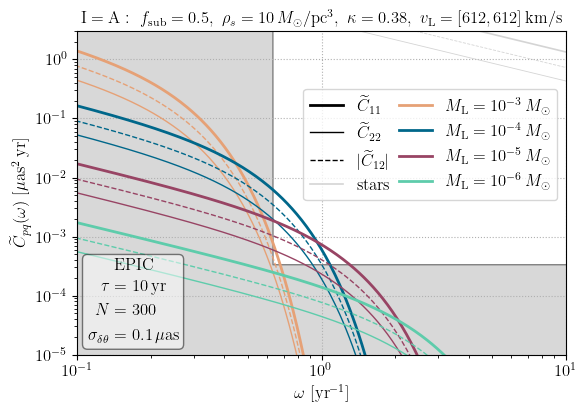

In [7]:
fig,ax = plt.subplots(1,1,figsize=(6.3,4.2))
#colors = sns.color_palette("husl", 4)
colors = [sns.color_palette(xgfs_fancy6)[i] for i in [2,3,4,5,6]]

ax.plot(vec_omega/year**-1, 0*arr_C_pq_DM[0,0,0,0]/(muas**2*year), color='k', lw=2, 
        label=r'$\widetilde{C}_{11}$')
ax.plot(vec_omega/year**-1, 0*arr_C_pq_DM[0,0,1,1]/(muas**2*year), color='k', lw=1,
        label=r'$\widetilde{C}_{22}$')
ax.plot(vec_omega/year**-1, 0*np.abs(arr_C_pq_DM[0,0,0,1])/(muas**2*year), color='k',lw=1,ls='dashed',
        label=r'$|\widetilde{C}_{12}|$')

idx_I = 0
for i in [idx_I]:
        
        # naive stellar PSD: plotted de-emphasized, since the stars are measured and
        # subtracted star by star via intensity-interferometric shape fits (companion paper)
        ax.plot(vec_omega/year**-1, arr_C_pq_star[i,0,0]/(muas**2*year), color=colors[4], lw=1.2, alpha=0.85,
                label='stars')
        ax.plot(vec_omega/year**-1, arr_C_pq_star[i,1,1]/(muas**2*year), color=colors[4], lw=0.6, alpha=0.85)
        ax.plot(vec_omega/year**-1, arr_C_pq_star[i,0,1]/(muas**2*year), color=colors[4], lw=0.6, alpha=0.85, ls='dashed')
        
        for j, M_L in enumerate(vec_M_L):
                ax.plot(vec_omega/year**-1, arr_C_pq_DM[i,j,0,0]/(muas**2*year), color=colors[j], lw=2, 
                        label=r'$M_\mathrm{L} = 10^{%.2g} \, M_\odot$' % np.log10(M_L/M_Solar))
                ax.plot(vec_omega/year**-1, arr_C_pq_DM[i,j,1,1]/(muas**2*year), color=colors[j], lw=1)
                        #label=r'$C^\mathrm{DM}_{22}, M_\mathrm{L} = 10^{%.2g} \, M_\odot$' % np.log10(M_L/M_Solar))
                ax.plot(vec_omega/year**-1, np.abs(arr_C_pq_DM[i,j,0,1])/(muas**2*year), color=colors[j],lw=1,ls='dashed')
                        #label=r'$C^\mathrm{DM}_{12}, M_\mathrm{L} = 10^{%.2g} \, M_\odot$' % np.log10(M_L/M_Solar))

ax.fill_between(vec_omega/year**-1,vec_C_inst/(muas**2*year),
                color=(0.5,0.5,0.5,1), facecolor=(0.5,0.5,0.5,0.3), ls='solid',lw=1)#label=r'$\mathrm{EPIC}$')


ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'$\omega~ [\mathrm{yr}^{-1}$]')
ax.set_ylabel(r'$\widetilde{C}_{pq}(\omega) ~[\mathrm{\mu as^2 \, yr}]$')
ax.grid(ls='dotted')
ax.set_xlim(1e-1,1e1);
ax.set_ylim(1e-5,3e0)
ax.legend(loc='center right', bbox_to_anchor=(1, 0.65),ncol=2,labelspacing=0.5, columnspacing=0.5);
ax.text(1.1e-1,1.5e-5,
        r'\begin{align*} \text{EPIC} \end{align*} \vspace{-3em} \begin{align*}\tau &= %.5g \,\mathrm{yr} \\ N &= %.5g \\ \sigma_{\delta \theta} &= %.5g \, \mathrm{ \mu as} \end{align*}'
        % ((tau/year),(N_obs),(sigma_delta_theta/muas)),
        ha='left',va='bottom',bbox=dict(boxstyle='round', facecolor='white', alpha=0.5));
ax.set_title(r'$\text{I}=\mathrm{%s}: ~f_\mathrm{sub} = %.1g, ~\rho_s = %.2g \,M_\odot/\mathrm{pc^3}, ~\kappa = %.2g, ~v_\mathrm{L} = [%.3g,%.3g] \,\mathrm{km/s}$'
              % (labels[idx_I], f_sub, (rho_s/(M_Solar/pc**3)), kappa_fit[idx_I], (v_lens[0]/(km/second)), (v_lens[1]/(km/second))),
              fontsize=12);
fig.savefig('../figs/CtildeA.pdf', bbox_inches='tight')

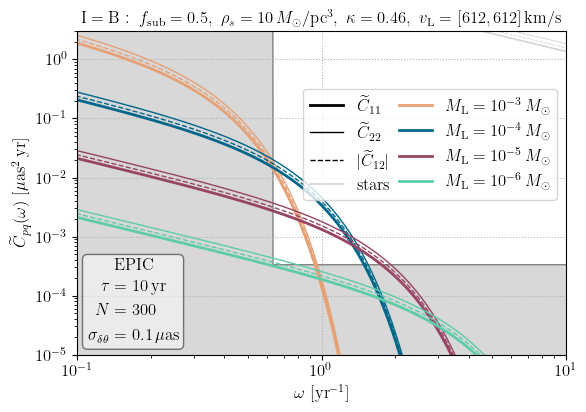

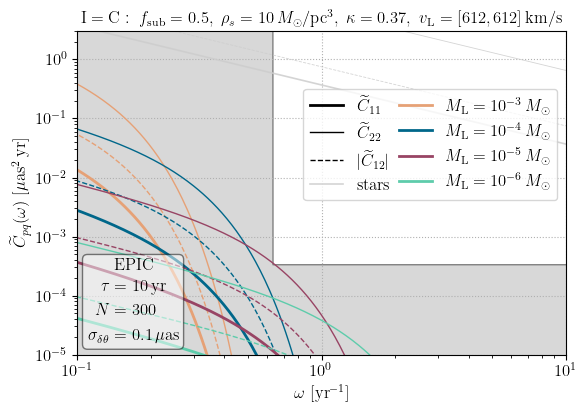

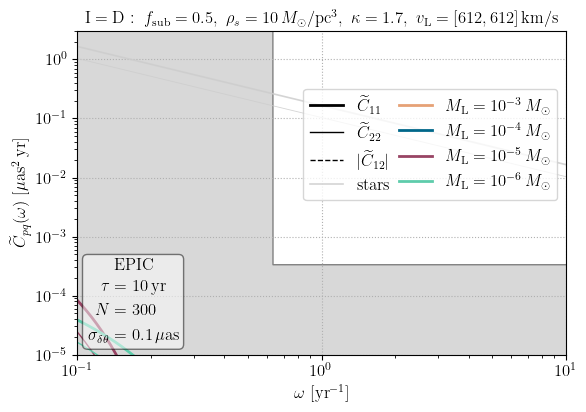

In [8]:
# same PSD, for the remaining images B, C, D (diagnostic; not saved to figs/)
for idx_I in [1, 2, 3]:
    fig,ax = plt.subplots(1,1,figsize=(6.3,4.2))
    #colors = sns.color_palette("husl", 4)
    colors = [sns.color_palette(xgfs_fancy6)[i] for i in [2,3,4,5,6]]

    ax.plot(vec_omega/year**-1, 0*arr_C_pq_DM[0,0,0,0]/(muas**2*year), color='k', lw=2, 
            label=r'$\widetilde{C}_{11}$')
    ax.plot(vec_omega/year**-1, 0*arr_C_pq_DM[0,0,1,1]/(muas**2*year), color='k', lw=1,
            label=r'$\widetilde{C}_{22}$')
    ax.plot(vec_omega/year**-1, 0*np.abs(arr_C_pq_DM[0,0,0,1])/(muas**2*year), color='k',lw=1,ls='dashed',
            label=r'$|\widetilde{C}_{12}|$')

    for i in [idx_I]:
        
            # naive stellar PSD: plotted de-emphasized, since the stars are measured and
            # subtracted star by star via intensity-interferometric shape fits (companion paper)
            ax.plot(vec_omega/year**-1, arr_C_pq_star[i,0,0]/(muas**2*year), color=colors[4], lw=1.2, alpha=0.85,
                    label='stars')
            ax.plot(vec_omega/year**-1, arr_C_pq_star[i,1,1]/(muas**2*year), color=colors[4], lw=0.6, alpha=0.85)
            ax.plot(vec_omega/year**-1, arr_C_pq_star[i,0,1]/(muas**2*year), color=colors[4], lw=0.6, alpha=0.85, ls='dashed')
        
            for j, M_L in enumerate(vec_M_L):
                    ax.plot(vec_omega/year**-1, arr_C_pq_DM[i,j,0,0]/(muas**2*year), color=colors[j], lw=2, 
                            label=r'$M_\mathrm{L} = 10^{%.2g} \, M_\odot$' % np.log10(M_L/M_Solar))
                    ax.plot(vec_omega/year**-1, arr_C_pq_DM[i,j,1,1]/(muas**2*year), color=colors[j], lw=1)
                            #label=r'$C^\mathrm{DM}_{22}, M_\mathrm{L} = 10^{%.2g} \, M_\odot$' % np.log10(M_L/M_Solar))
                    ax.plot(vec_omega/year**-1, np.abs(arr_C_pq_DM[i,j,0,1])/(muas**2*year), color=colors[j],lw=1,ls='dashed')
                            #label=r'$C^\mathrm{DM}_{12}, M_\mathrm{L} = 10^{%.2g} \, M_\odot$' % np.log10(M_L/M_Solar))

    ax.fill_between(vec_omega/year**-1,vec_C_inst/(muas**2*year),
                    color=(0.5,0.5,0.5,1), facecolor=(0.5,0.5,0.5,0.3), ls='solid',lw=1)#label=r'$\mathrm{EPIC}$')


    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel(r'$\omega~ [\mathrm{yr}^{-1}$]')
    ax.set_ylabel(r'$\widetilde{C}_{pq}(\omega) ~[\mathrm{\mu as^2 \, yr}]$')
    ax.grid(ls='dotted')
    ax.set_xlim(1e-1,1e1);
    ax.set_ylim(1e-5,3e0)
    ax.legend(loc='center right', bbox_to_anchor=(1, 0.65),ncol=2,labelspacing=0.5, columnspacing=0.5);
    ax.text(1.1e-1,1.5e-5,
            r'\begin{align*} \text{EPIC} \end{align*} \vspace{-3em} \begin{align*}\tau &= %.5g \,\mathrm{yr} \\ N &= %.5g \\ \sigma_{\delta \theta} &= %.5g \, \mathrm{ \mu as} \end{align*}'
            % ((tau/year),(N_obs),(sigma_delta_theta/muas)),
            ha='left',va='bottom',bbox=dict(boxstyle='round', facecolor='white', alpha=0.5));
    ax.set_title(r'$\text{I}=\mathrm{%s}: ~f_\mathrm{sub} = %.1g, ~\rho_s = %.2g \,M_\odot/\mathrm{pc^3}, ~\kappa = %.2g, ~v_\mathrm{L} = [%.3g,%.3g] \,\mathrm{km/s}$'
                  % (labels[idx_I], f_sub, (rho_s/(M_Solar/pc**3)), kappa_fit[idx_I], (v_lens[0]/(km/second)), (v_lens[1]/(km/second))),
                  fontsize=12);
    plt.show()

# Sensitivity

## Stellar background

In [9]:
# ---- Stellar microlensing background (Sec. III C): the companion paper's campaign
# rescaled to this survey ----
# Ref. [companionstars] measures and subtracts stellar microlenses through their
# intensity-interferometric image-shape distortions out to theta_fit = 10 muas (for
# M_* = 0.3 Msun) over a 33-epoch, 8-yr campaign. A star is detected once its shear
# contribution gamma_* = (theta_E,*/theta_sep)^2 accumulates chi^2 ~ n_obs (gamma_* SNR_1)^2
# above threshold, so the fitting radius grows as Eq. (theta_fit),
# theta_fit ~ theta_E,* SNR_1^(1/2) n_obs^(1/4). Rescaled to the N_obs epochs assumed here:
n_obs_companion = 33
theta_fit = 10 * muas * (N_obs / n_obs_companion)**0.25
print('theta_fit = %.3g muas' % (theta_fit/muas))

# expected number of stars inside the fitting region, N_fit^I = kappa_*^I Sigma_cr pi theta_fit^2 D_L^2 / M_*
N_fit = kappa_star * Sigma_crit(d_lens, d_source, d_lens_source) / M_star * np.pi * theta_fit**2 * d_lens**2
print('N_fit = %.2g (image A, kappa_* = %.3g)' % (N_fit, kappa_star))

Delta_theta = mu_tilde * tau   # angular distance swept per image over the campaign
print('Delta_theta = %.2g muas (image A)' % (Delta_theta[0]/muas))
print('theta_E_star = %.2g muas' % (theta_E_star/muas))

# Two residual terms, studied for image A only (adopted below as the per-image estimate):
# (1) worst-case acceleration variance from the nearest UNFITTED star, placed at theta_fit
#     (Eq. 3.24 of VanTilburg:2018ykj): ~ theta_fit^-6 ~ SNR_1^-3 n_obs^-3/2, i.e. it falls
#     FASTER with improving data than the instrumental floor of Eq. (noise_2).
sigma2_acc_unfitted_A = np.abs(np.linalg.det(inv_jacobian_fit[0])) * 4 * theta_E_star**4 * mu_tilde[0]**4 / theta_fit**6
# (2) FITTED-star subtraction residual: best-case variance 1.96e-4 muas^2/yr^4 over the
#     companion campaign; scales as sigma_delta_theta^2/(n_obs tau^4), i.e. tracks the
#     instrumental floor at a fixed multiple.
sigma2_acc_fitted_A = 1.96e-4 * muasyy**2 * (n_obs_companion/N_obs) * ((8*year)/tau)**4
sigma2_acc_star_A = sigma2_acc_unfitted_A + sigma2_acc_fitted_A
print('image A: unfitted = %.3g, fitted = %.3g, total = %.3g muas^2/yr^4'
      % (sigma2_acc_unfitted_A/muasyy**2, sigma2_acc_fitted_A/muasyy**2, sigma2_acc_star_A/muasyy**2))


theta_fit = 17.4 muas
N_fit = 7.7 (image A, kappa_* = 0.05)
Delta_theta = 9.9 muas (image A)
theta_E_star = 1.4 muas
image A: unfitted = 3.66e-06, fitted = 8.83e-06, total = 1.25e-05 muas^2/yr^4


## Instrument-limited

In [10]:
# Instrumental acceleration noise, Eq. (noise_2) -- identical to sigma_theta_ddot computed
# in the Parameters cell above (12 sqrt(5) = sqrt(720)); recomputed here as a cross-check.
sigma_theta_ddot = np.sqrt(720 * sigma_delta_theta**2 / (tau**4 * N_obs))

print(r'sigma_theta_ddot^2 = %.2g muas^2/yr^4' % (sigma_theta_ddot**2/muasyy**2))
print(r'sigma_theta_ddot = %.2g muas/yr^2' % (sigma_theta_ddot/muasyy))

sigma_theta_ddot^2 = 2.4e-06 muas^2/yr^4
sigma_theta_ddot = 0.0015 muas/yr^2


### Sensitivity in the $(M_\mathrm{L}, \rho_s)$ plane

The two images of a pair see statistically independent subhalo fields, so their
covariances add (Eq. observable_1):

\begin{align}
C^\mathrm{A,B}_{pq} = \big\langle (\theta^\mathrm{A}_p - \theta^\mathrm{B}_p) (\theta^\mathrm{A}_q - \theta^\mathrm{B}_q) \big\rangle = C^\mathrm{A}_{pq} + C^\mathrm{B}_{pq}.
\end{align}

For each point of the $(M_\mathrm{L}, \rho_s)$ grid we take the largest eigenvalue of
the $2\times2$ sky covariance and compare it to the white instrumental noise of
Eq. (noise_1) at the most favorable DFT frequency; variance $\mathrm{SNR} > 1$ means
that combination of $\kappa_\mathrm{L}$, $M_\mathrm{L}$ and $r_\mathrm{L}$ is
detectable. Each grid point is a *monochromatic* response, assigning the full
substructure convergence $f_\mathrm{sub}\kappa^\mathrm{I}$ to halos of a single mass.

Two simplifications, both stated in the paper: the transverse velocity is held at its
fiducial value rather than marginalized over (Sec. III B), and the stochastic
statistic uses the single best frequency rather than an optimally weighted sum over
modes (Sec. II E) --- conservative, since the spectrum is red and the lowest mode
dominates.


### Setup

In [11]:
# Grid for the (M_L, rho_s) plane of figs/SNR.pdf. r_L and rho_s are the free parameters;
# the halo mass follows from the profile convention of Sec. III B,
# M_L = 4 pi sqrt(e) rho_s r_L^3, and gamma_L = r_L/D_L is its angular size.
list_r_L = 10**np.arange(-4.5,1.5,0.04) * pc
list_rho_s = 10**np.arange(-2.,5.01,0.04) * M_Solar/pc**3
arr_r_L, arr_rho_s = np.meshgrid(list_r_L, list_rho_s)
arr_M_L = np.asarray([[4*np.pi*np.exp(1/2) * rho_s * r_L**3 for r_L in list_r_L] for rho_s in list_rho_s])
arr_gamma_L = arr_r_L / d_lens
arr_theta_E_L = theta_E(arr_M_L, d_lens, d_source, d_lens_source)

# Two frequency grids: the DFT modes omega_n = 2 pi n / tau actually sampled by the survey
# (stochastic channel, Eq. observable_1), and a much wider logarithmic grid reaching far
# below the band edge for the continuum omega-integrals of the proper-motion and
# acceleration channels (Eqs. est_1_var, observable_2), whose kernels peak there.
list_n = np.arange(1,N_obs)
list_omega = 2 * np.pi / tau * list_n
vec_omega_wide = np.logspace(-6,2,int(5e2)) * 2 * np.pi / tau

# Fiducial LambdaCDM rho_s(M_s) relation -- the gray band of figs/SNR.pdf. Subhalos are
# taken NFW with the median concentration c_200(M_200, x_sub) of Eq. (7) of Moline+2017,
# which is calibrated on subhalos (systematically more concentrated than field halos of
# the same mass) and depends on the distance x_sub = R_sub/R_200^host from the host
# center. Then r_s = r_200/c_200, rho_s = rho(r_s) -- the convention of Sec. III B -- and
# the plotted mass is the SCALE mass M_s = M(<r_s) = M_200 m(1)/m(c_200), not M_200. The
# band is bracketed by x_sub = 1 (field halos, bottom) and x_sub = 0.01 (top), with
# x_sub = 0.1 drawn in between; the dashed curve is B1422+231's own x_sub_fid = 0.03, the
# line-of-sight-weighted host distance of its images (params_B1422_231).
#
# This replaces the Wang+2020 FIELD-halo relation, which needed an ad hoc factor 20 on
# rho_s to reach the rho_s ~ 0.1-1 M_Solar/pc^3 of the collapse-redshift argument of
# Sec. IV A; the Moline+ subhalo relation lands there unaided.
list_M_200 = 10**np.arange(-8.,6.01,0.05) * M_Solar
list_x_sub = [1., 0.1, 0.01]
arr_M_s_band = np.zeros((len(list_x_sub),len(list_M_200)))
arr_rho_s_band = np.zeros_like(arr_M_s_band)
for i, x_sub in enumerate(list_x_sub):
    arr_M_s_band[i], arr_rho_s_band[i], _ = scale_params_NFW_Moline(list_M_200, x_sub)
list_M_s_pred, list_rho_s_pred, list_r_s_pred = scale_params_NFW_Moline(list_M_200, x_sub_fid)

# The three x_sub curves have slightly different M_s at fixed M_200, so the band fill is
# done on a common mass grid.
list_M_s_fill = np.logspace(-8,4,300) * M_Solar
arr_rho_s_fill = np.asarray([np.exp(np.interp(np.log(list_M_s_fill), np.log(M_s), np.log(rho_s)))
                             for M_s, rho_s in zip(arr_M_s_band, arr_rho_s_band)])
print('rho_s [M_Solar/pc^3] at M_s = 1e-6, 1 M_Solar:')
for i, x_sub in enumerate(list_x_sub):
    f = lambda t: np.exp(np.interp(np.log(t*M_Solar), np.log(arr_M_s_band[i]), np.log(arr_rho_s_band[i])))
    print('  x_sub = %5.3g:  %.2f, %.2f' % (x_sub, f(1e-6)/(M_Solar/pc**3), f(1.)/(M_Solar/pc**3)))


rho_s [M_Solar/pc^3] at M_s = 1e-6, 1 M_Solar:
  x_sub =     1:  0.20, 0.10
  x_sub =   0.1:  0.66, 0.30
  x_sub =  0.01:  1.50, 0.68


In [12]:
len(list_rho_s),len(list_r_L), np.shape(arr_gamma_L), np.shape(arr_M_L), len(list_omega)

(176, 150, (176, 150), (176, 150), 299)

### Scan for temporal power spectrum

In [13]:
arr_C_ij_DM = np.zeros((len(kappa_L),len(list_rho_s),len(list_r_L),2,2,len(list_omega)))
for i in range(len(kappa_L)):
    arr_C_ij_DM[i] = kappa_L[i] * arr_theta_E_L[:,:,None,None,None]**2 / list_omega * np.transpose(C_ij_integral(arr_gamma_L[:,:,None]/mu_tilde[i] * list_omega, zeta[i]),axes=(2,3,0,1,4))
# contract both indices with B^I: C~^I_pq = B^I_pi B^I_qj C~^I_ij (Eq. C)
arr_C_pq_DM = np.einsum('aqj,abcpjm->abcpqm',inv_jacobian_fit, np.einsum('api,abcijm->abcpjm', inv_jacobian_fit, arr_C_ij_DM))

# The two images of a pair see independent subhalo fields, so their PSDs add:
# C~^{I,I'}_pq = C~^I_pq + C~^{I'}_pq (Eq. observable_1).
N_images = len(kappa_L)
N_pairs = N_images * (N_images - 1) // 2
arr_C_pq_pair = np.zeros((N_pairs,len(list_rho_s),len(list_r_L),2,2,len(list_omega))) # shape = N_pairs, len(list_rho_s), len(list_r_L), 2, 2,  len(list_omega)

count = 0
for i in range(N_images):
    for j in range(i+1,N_images):
        arr_C_pq_pair[count] = arr_C_pq_DM[i] + arr_C_pq_DM[j]
        count+=1

arr_C_pq_pair = np.transpose(arr_C_pq_pair, axes=(1,2,0,5,3,4)) # reshape = len(list_rho_s), len(list_r_L), N_pairs, len(list_omega), 2, 2
arr_C_pair_max = np.max(np.linalg.eigvals(arr_C_pq_pair),axis=-1) # largest eigenvalue of the 2x2 sky covariance

arr_C_inst = C_inst(list_omega, tau=tau, N_obs=N_obs, sigma_delta_theta=sigma_delta_theta) #[None,None,None,:]

# Stochastic-channel variance SNR: best (pair, DFT mode) excess power over the white floor.
arr_SNR_EPIC = np.max(arr_C_pair_max / arr_C_inst, axis=(-2,-1))

### Subtraction

In [14]:
# Effect of fitting out the bulk proper motion on the stochastic channel: removing a linear
# trend from the time series suppresses DFT mode n by 1 - cos_fac, with
# cos_fac = (12/N^2)/[1 - cos(2 pi n/N)], which bites only at the lowest few modes.
# Diagnostic only -- figs/SNR.pdf uses the unsubtracted arr_SNR_EPIC, since in the full
# analysis the proper motion is a fitted nuisance parameter rather than a hard projection.
cos_fac = (12/N_obs**2) / (1 - np.cos(2 * np.pi * list_n / N_obs))
arr_C_pair_max_sub = (1 - cos_fac) * arr_C_pair_max
arr_SNR_EPIC_tilde = np.max(arr_C_pair_max_sub / arr_C_inst, axis=(-2,-1))

### Scan for proper motion and acceleration

In [15]:
# Smearing form factors F_1, F_2 of App. Proper Motion & Acceleration Estimators, which
# correct the ideal omega^2 / omega^4 derivative weights for the finite fit window tau.
# Both -> 1 as omega tau -> 0 and roll off as (omega tau)^-4 / (omega tau)^-6 above it.
def smear_F1(a):
    return np.heaviside(-a + 1e-2,0) + np.heaviside(a - 1e-2,0) * 144 * (a * np.cos(a/2) - 2 * np.sin(a/2))**2 / a**6
def smear_F2(a):
    return np.heaviside(-a + 1e-2,0) + np.heaviside(a - 1e-2,0) * 14400 * (6 * a * np.cos(a/2) + (-12 + a**2) * np.sin(a/2))**2 / a**10

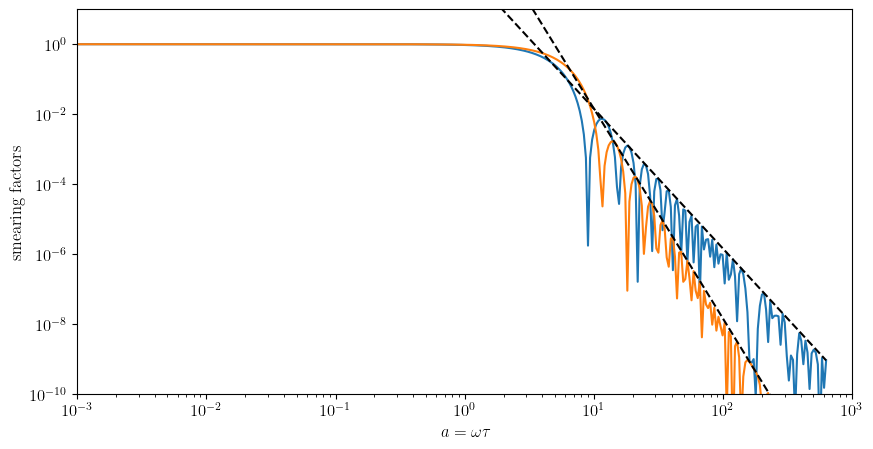

In [16]:
a = vec_omega_wide[1:] * tau
vec_F1 = smear_F1(a)
vec_F2 = smear_F2(a)
fig,ax = plt.subplots(1,1,figsize=(10,5))
ax.plot(a,vec_F1)
ax.plot(a,vec_F2)
ax.plot(a,144 * a**-4,'--k')
ax.plot(a,14400 * a**-6,'--k')
ax.set_xscale('log'); ax.set_yscale('log');
ax.set_xlim(1e-3,1e3);
ax.set_ylim(1e-10,1e1);
ax.set_ylabel(r'smearing factors')
ax.set_xlabel(r'$a = \omega \tau$');

In [17]:
arr_C_ij_DM_wide = np.zeros((len(kappa_L),len(list_rho_s),len(list_r_L),2,2,len(vec_omega_wide)))
for i in range(len(kappa_L)):
    arr_C_ij_DM_wide[i] = kappa_L[i] * arr_theta_E_L[:,:,None,None,None]**2 / vec_omega_wide * np.transpose(C_ij_integral(arr_gamma_L[:,:,None]/mu_tilde[i] * vec_omega_wide, zeta[i]),axes=(2,3,0,1,4))
# contract both indices with B^I: C~^I_pq = B^I_pi B^I_qj C~^I_ij (Eq. C)
arr_C_pq_DM_wide = np.einsum('aqj,abcpjm->abcpqm',inv_jacobian_fit, np.einsum('api,abcijm->abcpjm', inv_jacobian_fit, arr_C_ij_DM_wide))

# independent sightlines, so the pair PSD is the sum of the two image PSDs
N_images = len(kappa_L)
N_pairs = N_images * (N_images - 1) // 2
arr_C_pq_pair_wide = np.zeros((N_pairs,len(list_rho_s),len(list_r_L),2,2,len(vec_omega_wide))) # shape = N_pairs, len(list_rho_s), len(list_r_L), 2, 2,  len(vec_omega_wide)

count = 0
for i in range(N_images):
    for j in range(i+1,N_images):
        arr_C_pq_pair_wide[count] = arr_C_pq_DM_wide[i] + arr_C_pq_DM_wide[j]
        count+=1
        

# Proper-motion and acceleration covariances, Eqs. (est_1_var) and (observable_2): the
# omega^2 F_1 and omega^4 F_2 moments of the pair PSD. The leading factor 2 counts the
# negative frequencies, since C~ is a two-sided PSD.
# arr_mu_pq_pair = 2 * np.sum((vec_omega_wide[1:] - vec_omega_wide[:-1])/(2*np.pi) * vec_omega_wide[1:]**2 * arr_C_pq_pair_wide[:,:,:,:,:,1:],axis=-1)
# arr_acc_pq_pair = 2 * np.sum((vec_omega_wide[1:] - vec_omega_wide[:-1])/(2*np.pi) * vec_omega_wide[1:]**4 * arr_C_pq_pair_wide[:,:,:,:,:,1:],axis=-1)
d_omega_wide = vec_omega_wide[1:] - vec_omega_wide[:-1]
a = vec_omega_wide[1:] * tau
vec_F1 = smear_F1(a)
vec_F2 = smear_F2(a)
arr_mu_pq_pair = 2 * np.sum(vec_F1 * d_omega_wide / (2*np.pi) * vec_omega_wide[1:]**2 * arr_C_pq_pair_wide[:,:,:,:,:,1:],axis=-1)
arr_acc_pq_pair = 2 * np.sum(vec_F2 * d_omega_wide / (2*np.pi) * vec_omega_wide[1:]**4 * arr_C_pq_pair_wide[:,:,:,:,:,1:],axis=-1)

arr_mu_pq_pair = np.transpose(arr_mu_pq_pair, axes=(1,2,0,3,4)) # reshape = len(list_rho_s), len(list_r_L), N_pairs, 2, 2
arr_acc_pq_pair = np.transpose(arr_acc_pq_pair, axes=(1,2,0,3,4)) # reshape = len(list_rho_s), len(list_r_L), N_pairs, 2, 2

arr_mu_pair_max = np.max(np.linalg.eigvals(arr_mu_pq_pair),axis=-1) # largest eigenvalue (2x2 sky)
arr_acc_pair_max = np.max(np.linalg.eigvals(arr_acc_pq_pair),axis=-1) # largest eigenvalue (2x2 sky)

# Variance SNRs, maximized over image pairs. The proper-motion channel is quoted two ways:
# against the measurement noise sigma_theta_dot (arr_SNR_EPIC_mu, not plotted, since the
# mean proper motion is degenerate with the macro-model), and against mu_tilde^I itself --
# the relative precision Delta of the teal contours of figs/SNR.pdf.
arr_SNR_EPIC_mu = np.max(arr_mu_pair_max / sigma_theta_dot**2, axis=-1)
arr_SNR_EPIC_mu_tilde = np.max(arr_mu_pair_max / np.max(mu_tilde)**2, axis=-1)
arr_SNR_EPIC_acc = np.max(arr_acc_pair_max / sigma_theta_ddot**2, axis=-1)

# Effective noise for a differential image pair: the instrumental floor of Eq. (noise_2)
# plus the worst-case post-subtraction stellar residual of both images. Only image A's
# stellar budget has been studied (companion paper), so it is adopted as the per-image
# estimate and doubled -- the 'stars' contour of figs/SNR.pdf and Tab. tab:bottomline.
sigma2_acc_eff = sigma_theta_ddot**2 + 2 * sigma2_acc_star_A
print('effective pair noise = %.3g muas^2/yr^4 (%.1f x instrumental)'
      % (sigma2_acc_eff/muasyy**2, sigma2_acc_eff/sigma_theta_ddot**2))
arr_SNR_EPIC_acc_star = np.max(arr_acc_pair_max / sigma2_acc_eff, axis=-1)


effective pair noise = 2.74e-05 muas^2/yr^4 (11.4 x instrumental)


### Acceleration figure

In [18]:
list_rho_s.shape, list_r_L.shape, arr_acc_pair_max.shape, arr_M_L.shape

((176,), (150,), (176, 150, 6), (176, 150))

In [19]:
colors = sns.color_palette(xgfs_fancy6); colors

[(0.33725490196078434, 0.39215686274509803, 0.10196078431372549),
 (0.7529411764705882, 0.6862745098039216, 0.984313725490196),
 (0.9019607843137255, 0.6313725490196078, 0.4627450980392157),
 (0.0, 0.403921568627451, 0.5411764705882353),
 (0.596078431372549, 0.26666666666666666, 0.39215686274509803),
 (0.3686274509803922, 0.8, 0.6705882352941176),
 (0.803921568627451, 0.803921568627451, 0.803921568627451)]

rho_s = 1 M_Solar / pc^3
rho_s = 10 M_Solar / pc^3


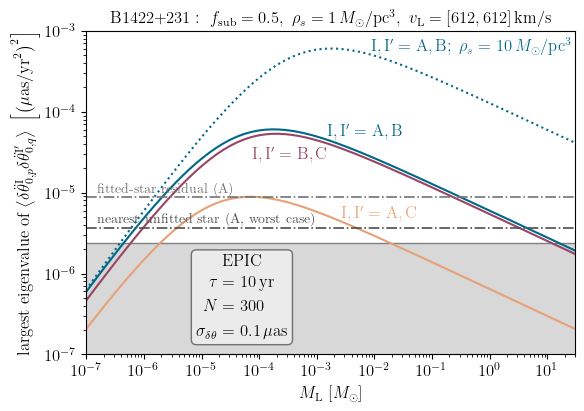

In [20]:
idx_rho_1 = 50; print('rho_s = %.2g M_Solar / pc^3' % (list_rho_s[idx_rho_1]/(M_Solar / pc**3)))
idx_rho_2 = 75; print('rho_s = %.2g M_Solar / pc^3' % (list_rho_s[idx_rho_2]/(M_Solar / pc**3)))


fig,ax = plt.subplots(1,1,figsize=(6.3,4.2))
#colors = sns.color_palette("husl", 4)

ax.fill_between(arr_M_L[idx_rho_1]/M_Solar,sigma_theta_ddot**2 / muasyy**2,color=(0.5,0.5,0.5,1), facecolor=(0.5,0.5,0.5,0.3))

# Gray region: the instrumental acceleration floor of Eq. (noise_2). The dash-dotted lines
# added further down are the stellar-microlensing benchmark levels of Sec. III C -- the
# worst-case bound from the nearest unfitted star and the fitted-star subtraction residual.
# Both are smooth, single-perturber trends that can be certified against (chi^2 of the
# compact-source visibility model) and jointly fit, so neither is an irreducible floor.

ax.plot(arr_M_L[idx_rho_1]/M_Solar, arr_acc_pair_max[idx_rho_1,:,0] / muasyy**2, color=colors[3], label=r'$\mathrm{I,I^\prime = A,B}$') # AB
ax.plot(arr_M_L[idx_rho_1]/M_Solar, arr_acc_pair_max[idx_rho_1,:,3] / muasyy**2, color=colors[4], label=r'$\mathrm{I,I^\prime = B,C}$') # BC
ax.plot(arr_M_L[idx_rho_1]/M_Solar, arr_acc_pair_max[idx_rho_1,:,1] / muasyy**2, color=colors[2], label=r'$\mathrm{I,I^\prime = A,C}$') # AC
ax.plot(arr_M_L[idx_rho_2]/M_Solar, arr_acc_pair_max[idx_rho_2,:,0] / muasyy**2, ls='dotted', color=colors[3], label=r'$\mathrm{I,I^\prime = A,B}$\\$\rho_s = 10\,M_\odot / \mathrm{pc}^3$') # AB
#ax.plot(arr_M_L[idx_rho_1]/M_Solar, arr_acc_pair_max[idx_rho_1,:,2] / muasyy**2) # AD
#ax.plot(arr_M_L[idx_rho_1]/M_Solar, arr_acc_pair_max[idx_rho_1,:,4] / muasyy**2) # BD
#ax.plot(arr_M_L[idx_rho_1]/M_Solar, arr_acc_pair_max[idx_rho_1,:,5] / muasyy**2) # CD
#ax.legend(loc='upper right', bbox_to_anchor=(1, 1),ncol=2,labelspacing=0.5, columnspacing=0.5)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(1e-7,3e1)
ax.set_ylim(1e-7,1e-3)
ax.set_xlabel(r'$M_\mathrm{L}~[M_\odot]$');
ax.set_ylabel(r'largest eigenvalue of $\big \langle \delta \ddot \theta^\mathrm{I}_{0,p} \delta \ddot \theta^\mathrm{I^\prime}_{0,q} \big \rangle~\left[\left(\mathrm{\mu as / yr}^2\right)^2\right]$')

idx_lab_0 = 78
ax.text(arr_M_L[idx_rho_1,idx_lab_0]/M_Solar,arr_acc_pair_max[idx_rho_1,idx_lab_0,0]/muasyy**2,r'$\mathrm{I,I^\prime = A,B}$',color=colors[3],ha='left',va='bottom')
idx_lab_1 = 78
ax.text(arr_M_L[idx_rho_1,idx_lab_1]/M_Solar,0.9*arr_acc_pair_max[idx_rho_1,idx_lab_1,3]/muasyy**2,r'$\mathrm{I,I^\prime = B,C}$',color=colors[4],ha='right',va='top')
idx_lab_2 = 80
ax.text(arr_M_L[idx_rho_1,idx_lab_2]/M_Solar,arr_acc_pair_max[idx_rho_1,idx_lab_2,1]/muasyy**2,r'$\mathrm{I,I^\prime = A,C}$',color=colors[2],ha='left',va='bottom')
idx_lab_3 = 76
ax.text(arr_M_L[idx_rho_2,idx_lab_3]/M_Solar,arr_acc_pair_max[idx_rho_2,idx_lab_3,0]/muasyy**2,r'$\mathrm{I,I^\prime = A,B};~\rho_s = 10\,M_\odot / \mathrm{pc}^3$',color=colors[3],ha='left',va='bottom')

# stellar-microlensing residual levels at image A (Sec. III C), rescaled to this
# survey (theta_fit ~ 17 muas): worst-case unfitted star and fitted-star residual.
ax.axhline(sigma2_acc_fitted_A / muasyy**2, color=(0.45,0.45,0.45), lw=1.2, ls='dashdot')
ax.text(1.5e-7, 1.03*sigma2_acc_fitted_A/muasyy**2, r'fitted-star residual (A)',
        fontsize=10, color=(0.45,0.45,0.45), ha='left', va='bottom')
ax.axhline(sigma2_acc_unfitted_A / muasyy**2, color=(0.3,0.3,0.3), lw=1.2, ls='dashdot')
ax.text(1.5e-7, 1.03*sigma2_acc_unfitted_A/muasyy**2, r'nearest unfitted star (A, worst case)',
        fontsize=10, color=(0.3,0.3,0.3), ha='left', va='bottom')


ax.text(5e-5,1.7e-6,
        r'\begin{align*} \text{EPIC} \end{align*} \vspace{-3em} \begin{align*}\tau &= %.5g \,\mathrm{yr} \\ N &= %.5g \\ \sigma_{\delta \theta} &= %.5g \, \mathrm{ \mu as} \end{align*}'
        % ((tau/year),(N_obs),(sigma_delta_theta/muas)),
        ha='center',va='top',bbox=dict(boxstyle='round', facecolor='white', alpha=0.5));

ax.set_title(r'$\mathrm{B1422{+}231}: ~f_\mathrm{sub} = %.1g, ~\rho_s = %.2g \,M_\odot/\mathrm{pc^3}, ~v_\mathrm{L} = [%.3g,%.3g] \,\mathrm{km/s}$'
              % (f_sub, (list_rho_s[idx_rho_1]/(M_Solar/pc**3)), (v_lens[0]/(km/second)), (v_lens[1]/(km/second))),
              fontsize=12);
fig.savefig('../figs/acc.pdf', bbox_inches='tight')

### Reference

\begin{align}
\rho_s = \frac{M_\mathrm{L}}{4\pi \sqrt{e}\, r_\mathrm{L}^3}
\end{align}

In [21]:
# Diagonal reference lines of constant lens radius r_L in the (M_L, rho_s) plane,
# rho_s = M_L/(4 pi sqrt(e) r_L^3).
list_r_L_ref = np.logspace(-4,1,6) * pc
list_M_ref = np.logspace(-10,5,100) * M_Solar
arr_rho_s_ref = np.asarray([list_M_ref / (4*np.pi*np.exp(1/2)*r_L**3) for r_L in list_r_L_ref])
int_rho_s_ref_1 = interp1d(list_M_ref, arr_rho_s_ref[0], kind='linear', bounds_error=False, fill_value='extrapolate')
int_rho_s_ref_2 = interp1d(list_M_ref, arr_rho_s_ref[1], kind='linear', bounds_error=False, fill_value='extrapolate')
int_rho_s_ref_3 = interp1d(list_M_ref, arr_rho_s_ref[2], kind='linear', bounds_error=False, fill_value='extrapolate')
int_rho_s_ref_4 = interp1d(list_M_ref, arr_rho_s_ref[3], kind='linear', bounds_error=False, fill_value='extrapolate')
int_rho_s_ref_5 = interp1d(list_M_ref, arr_rho_s_ref[4], kind='linear', bounds_error=False, fill_value='extrapolate')
int_rho_s_ref_6 = interp1d(list_M_ref, arr_rho_s_ref[5], kind='linear', bounds_error=False, fill_value='extrapolate')

### Plot

In [22]:
colors = sns.color_palette(xgfs_fancy6); colors

[(0.33725490196078434, 0.39215686274509803, 0.10196078431372549),
 (0.7529411764705882, 0.6862745098039216, 0.984313725490196),
 (0.9019607843137255, 0.6313725490196078, 0.4627450980392157),
 (0.0, 0.403921568627451, 0.5411764705882353),
 (0.596078431372549, 0.26666666666666666, 0.39215686274509803),
 (0.3686274509803922, 0.8, 0.6705882352941176),
 (0.803921568627451, 0.803921568627451, 0.803921568627451)]

/var/folders/4c/r0fv34l54990y0356vhxlw7c0000gn/T/ipykernel_6744/2928029807.py:42: RuntimeWarning: divide by zero encountered in log10
  cs_SNR = ax.contour(arr_M_L/M_Solar, arr_rho_s/(M_Solar/pc**3), np.log10(arr_SNR_EPIC), colors=3*[colors[2]], linewidths=[4,2,1], levels=[0,2,4])


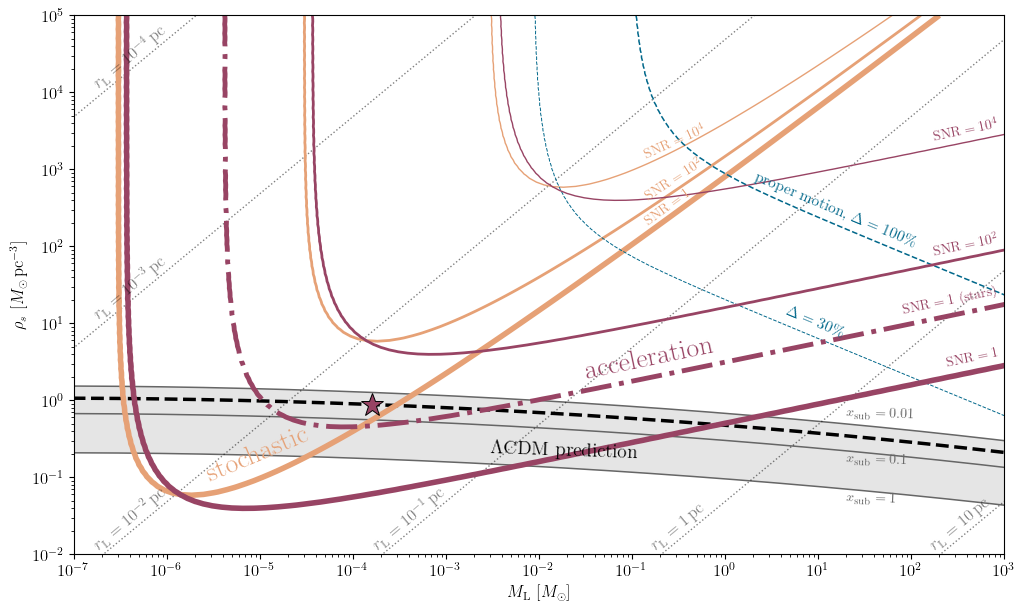

In [23]:
fig,ax = plt.subplots(1,1,figsize=(12,7))
rotation = 40; 
rotation_2 = np.arctan(np.tan(rotation*degree) / 4) / degree
rotation_3 = np.arctan(np.tan(rotation*degree) / 2) / degree
#ax.scatter(arr_M_L/M_Solar, arr_rho_s/(M_Solar/pc**3), c=np.log10(arr_r_L/pc), cmap='viridis', s=2);

# Fiducial LambdaCDM rho_s(M_s) relation (see the grid cell above for its construction):
# NFW subhalos with the Moline+2017 concentrations. The gray band spans host distances
# x_sub = 1 (field halos, lower edge) to x_sub = 0.01 (upper edge), bracketing the three
# thin gray lines at x_sub = {1, 0.1, 0.01}; the black dashed curve is x_sub = 0.03, the
# line-of-sight-weighted value at B1422+231's images A, B, C (params_B1422_231).
ax.fill_between(list_M_s_fill/M_Solar, arr_rho_s_fill[0]/(M_Solar/pc**3), arr_rho_s_fill[-1]/(M_Solar/pc**3),
                color=(0,0,0,0.10), lw=0)
for i, x_sub in enumerate(list_x_sub):
    ax.plot(arr_M_s_band[i]/M_Solar, arr_rho_s_band[i]/(M_Solar/pc**3), color=(0.4,0.4,0.4), lw=1.1)
ax.plot(list_M_s_pred/M_Solar, list_rho_s_pred/(M_Solar/pc**3), 'k--', lw=2.5)
ax.text(3e-3, 0.225, r'$\Lambda$CDM prediction', color='k', fontsize=14, ha='left', va='center', rotation=-2)
# x_sub labels: the two lower lines are labelled just below themselves (the 0.5-dex gap
# above the x_sub = 1 line is the roomiest part of the band), the top one just above.
M_lab = 2e1
for i, (lab, va, off) in enumerate(zip([r'$x_\mathrm{sub} = 1$', r'$x_\mathrm{sub} = 0.1$', r'$x_\mathrm{sub} = 0.01$'],
                                       ['top', 'top', 'bottom'], [0.93, 0.93, 1.06])):
    rho_lab = np.exp(np.interp(np.log(M_lab*M_Solar), np.log(arr_M_s_band[i]), np.log(arr_rho_s_band[i])))
    ax.text(M_lab, off*rho_lab/(M_Solar/pc**3), lab,
            color=(0.4,0.4,0.4), fontsize=10, ha='left', va=va, rotation=-2)

# Peak acceleration-channel variance SNR along the fiducial (x_sub = 0.03) CDM relation
# (impact_numbers.py): 2.0 against the worst-case stellar residual, 23 on certifiably
# star-free data. The star marker is the former, the value quoted in Sec. IV B and
# Tab. tab:bottomline.
M_peak_CDM = 1.6e-4
rho_peak_CDM = np.interp(np.log10(M_peak_CDM), np.log10(list_M_s_pred/M_Solar), list_rho_s_pred/(M_Solar/pc**3))
ax.plot([M_peak_CDM],[rho_peak_CDM], marker='*', ms=17, color=colors[4], mec='k', mew=0.7, zorder=5)
# ax.text(1.5*M_peak_CDM, 1.12*rho_peak_CDM, r'$\mathrm{SNR}\approx1.2$', rotation=rotation_2, color=colors[4], fontsize=13, ha='left', va='bottom')

for i in range(len(list_r_L_ref)):
    ax.plot(list_M_ref/M_Solar, arr_rho_s_ref[i]/(M_Solar/pc**3), color=(0,0,0,0.5), ls='dotted', lw=1)
# Channel contours. Stochastic (Eq. observable_1) and acceleration (Eq. observable_2) are
# both instrument-limited at SNR = 1, 1e2, 1e4; the extra dot-dashed acceleration contour
# adds the worst-case stellar residual, which burdens only that channel. The proper-motion
# contours are relative precisions Delta = 30%, 100% of mu_tilde^I, not SNRs.
cs_SNR = ax.contour(arr_M_L/M_Solar, arr_rho_s/(M_Solar/pc**3), np.log10(arr_SNR_EPIC), colors=3*[colors[2]], linewidths=[4,2,1], levels=[0,2,4])
cs_SNR_mu = ax.contour(arr_M_L/M_Solar, arr_rho_s/(M_Solar/pc**3), np.log10(arr_SNR_EPIC_mu_tilde), linestyles='dashed',colors=2*[colors[3]],linewidths=[0.7,1.1], levels=[np.log10(0.3**2),0])
cs_SNR_acc = ax.contour(arr_M_L/M_Solar, arr_rho_s/(M_Solar/pc**3), np.log10(arr_SNR_EPIC_acc), colors=3*[colors[4]], linewidths=[4,2,1], levels=[0,2,4])
cs_SNR_acc_star = ax.contour(arr_M_L/M_Solar, arr_rho_s/(M_Solar/pc**3), np.log10(arr_SNR_EPIC_acc_star), colors=[colors[4]], linestyles='dashdot', linewidths=[3.5], levels=[0])
#cs_SNR_tilde = ax.contour(arr_M_L/M_Solar, arr_rho_s/(M_Solar/pc**3), np.log10(arr_SNR_EPIC_tilde), cmap='magma', linewidths=2, levels=range(0,7))
#ax.clabel(cs_SNR_mu, inline=True, fontsize=20) 

xlim = (1e-7,1e3); ax.set_xlim(xlim);
ylim = (1e-2,1e5); ax.set_ylim(ylim);
ax.set_xscale('log');
ax.set_yscale('log');
ax.set_xlabel(r'$M_\mathrm{L}~[M_\odot]$');
ax.set_ylabel(r'$\rho_s~[M_\odot \, \mathrm{pc}^{-3}]$');
ax.set_xticks(np.logspace(np.log10(xlim[0]),np.log10(xlim[1]),1+int(np.log10(xlim[1]/xlim[0]))),minor=False);
ax.set_xticks(np.outer(np.logspace(np.log10(xlim[0]),np.log10(xlim[1])-1,int(np.log10(xlim[1]/xlim[0]))),range(1,10)).flatten(),minor=True);
ax.text(1.5e-7,1.4*int_rho_s_ref_1(1.5e-7*M_Solar) / (M_Solar/pc**3),r'$r_\mathrm{L} = 10^{-4} \, \mathrm{pc}$', color=(0,0,0,0.5), ha='left', va='bottom', rotation=rotation)
ax.text(1.5e-7,1.4*int_rho_s_ref_2(1.5e-7*M_Solar) / (M_Solar/pc**3),r'$r_\mathrm{L} = 10^{-3} \, \mathrm{pc}$', color=(0,0,0,0.5), ha='left', va='bottom', rotation=rotation)
ax.text(1.5e-7,1.4*int_rho_s_ref_3(1.5e-7*M_Solar) / (M_Solar/pc**3),r'$r_\mathrm{L} = 10^{-2} \, \mathrm{pc}$', color=(0,0,0,0.5), ha='left', va='bottom', rotation=rotation)
ax.text(1.5e-4,1.4*int_rho_s_ref_4(1.5e-4*M_Solar) / (M_Solar/pc**3),r'$r_\mathrm{L} = 10^{-1} \, \mathrm{pc}$', color=(0,0,0,0.5), ha='left', va='bottom', rotation=rotation)
ax.text(1.5e-1,1.4*int_rho_s_ref_5(1.5e-1*M_Solar) / (M_Solar/pc**3),r'$r_\mathrm{L} = 1 \, \mathrm{pc}$', color=(0,0,0,0.5), ha='left', va='bottom', rotation=rotation)
ax.text(1.5e2,1.4*int_rho_s_ref_6(1.5e2*M_Solar) / (M_Solar/pc**3),r'$r_\mathrm{L} = 10 \, \mathrm{pc}$', color=(0,0,0,0.5), ha='left', va='bottom', rotation=rotation)

ax.text(2.4e-6,7.5e-2,"stochastic",color=colors[2],fontsize=20,ha='left',va='bottom',rotation=rotation_3)
ax.text(1.3e-1,1.76e2,r"$\mathrm{SNR} = 1$",color=colors[2],fontsize=10,ha='left',va='bottom',rotation=36)
ax.text(1.3e-1,3.7e2,r"$\mathrm{SNR} = 10^2$",color=colors[2],fontsize=10,ha='left',va='bottom',rotation=33)
ax.text(1.3e-1,1.3e3,r"$\mathrm{SNR} = 10^4$",color=colors[2],fontsize=10,ha='left',va='bottom',rotation=24)

ax.text(1.2e2,9e1,r"proper motion, $\Delta = 100\%$",color=colors[3],va='bottom',ha='right',fontsize=11,rotation=-rotation_3)
ax.text(2e1,6e0,r"$\Delta = 30\%$",color=colors[3],fontsize=11,va='bottom',ha='right',rotation=-rotation_3)


ax.text(3e-2,1.63e0,"acceleration",color=colors[4],fontsize=20,rotation=rotation_2,va='bottom',ha='left')
ax.text(9e2,2.51e0,r"$\mathrm{SNR} = 1$",color=colors[4],fontsize=10,ha='right',va='bottom',rotation=rotation_2)
ax.text(9e2,1.18e1,r"$\mathrm{SNR} = 1$ (stars)",color=colors[4],fontsize=10,ha='right',va='bottom',rotation=rotation_2)
ax.text(9e2,7.07e1,r"$\mathrm{SNR} = 10^2$",color=colors[4],fontsize=10,ha='right',va='bottom',rotation=rotation_2)
ax.text(9e2,2.20e3,r"$\mathrm{SNR} = 10^4$",color=colors[4],fontsize=10,ha='right',va='bottom',rotation=rotation_2);

fig.savefig('../figs/SNR.pdf', bbox_inches='tight')

# Part II --- Cluster lens: SDSS J1029+2623

Cluster-lens analogue of Part I: a three-image quasar at $z_\mathrm{S} = 2.1992$
behind a galaxy *cluster* at $z_\mathrm{L} = 0.588$ (image separation $22.5''$),
with the convergence/shear at the images taken from the Acebron+2022
reconstruction (`params_J1029_2623.py`). Produces the direct analogues of the
Part I figures, `figs/CtildeC-J1029.pdf` (stochastic PSD, cf. `CtildeA.pdf`) and
`figs/acc-J1029.pdf` (differential acceleration, cf. `acc.pdf`).

Three things differ from the galaxy lens:

1. **Kinematics.** The effective lens velocity is the cluster bulk motion
   (474 km/s) plus a *moving-clump* member-halo term ($f_\mathrm{gal} = 0.2$ of
   the local deflection gradient orbiting at $\sigma_v = 1000$ km/s), giving
   $v_\mathrm{eff} \approx 552$ km/s; the microhalos' own dispersion enters the
   sweep rate unmagnified.
2. **Stellar background.** $\kappa_* \approx 0.003$ (vs $\approx 0.05$ for the
   galaxy lens): the images form in the DM-dominated cluster outskirts, so the
   rare stellar perturbers are single, identifiable trends rather than a
   stochastic background.
3. **Finite source.** J1029+2623 is faint, so the optical accretion-disk size
   matters: the magnified source size $\theta^\mathrm{I}_\mathrm{src}$ acts as a
   high-pass filter in halo mass, implemented by `C_ij_integral_src`
   (quadrature $x_k \to \sqrt{x_k^2 + x_\mathrm{src}^2}$).

The `from params_J1029_2623 import *` below rebinds the system-level names set by
Part I; see the run-order note at the top.

In [24]:
from preamble import *
from natural_units_GeV import *
from macro_lens_functions import *
from sensitivity_functions import *
# NOTE: this star-import deliberately rebinds the system-level names from the
# galaxy lens (d_lens, z_lens, kappa_fit, inv_jacobian_fit, mag_fit, eigvals_fit,
# labels, kappa_star, M_star, theta_E_star, mu_L_int, v_lens_fid, ...) to
# their SDSS J1029+2623 values. Everything below refers to the cluster lens.
from params_J1029_2623 import *

xgfs_fancy6 = 255**-1 * np.asarray([(86, 100, 26), (192, 175, 251), (230, 161, 118),
                                    (0, 103, 138), (152, 68, 100), (94, 204, 171), (205, 205, 205)])

R_200^cluster = 973 kpc, x_sub = 0.133 (projected 0.098)


In [25]:
# ---------------------------------------------------------------------------
# survey + lens-velocity configuration
# ---------------------------------------------------------------------------
v_obs = np.asarray([0, 0]) * km / second
v_lens = v_lens_fid   # effective fiducial |v_L| ~ 552 km/s: bulk 474 km/s in quadrature with
                      # the moving member-halo term sqrt(2) f_gal sigma_v (see params_J1029_2623)
v_source = np.asarray([0, 0]) * km / second

# fiducial differential-astrometry survey. J1029 is too faint for intensity
# interferometry (EPIC); we take a fiducial optical imager/interferometer
# light-centroiding precision, conservative relative to EPIC's 0.1 muas.
tau = 10 * year
sigma_delta_theta = 1.0 * muas
N_obs = 300

sigma_theta_dot = 2 * np.sqrt(3) * sigma_delta_theta / np.sqrt(N_obs * tau**2)
sigma_theta_ddot = 12 * np.sqrt(5) * sigma_delta_theta / np.sqrt(N_obs * tau**4)

f_sub = 0.5
kappa_L = kappa_fit * f_sub        # substructure convergence kappa_L^I at the images

vec_mu_source = mu_rel(v_obs, v_lens, v_source, z_lens, z_source, d_lens, d_source, d_lens_source)
vec_mu_tilde = np.tensordot(inv_jacobian_fit, vec_mu_source, axes=1)   # magnified image proper motion (bulk)
mu_tilde_bulk = np.linalg.norm(vec_mu_tilde, axis=1)
# Sweep rate d/dt[theta^I - theta_L] = B^I mu - mu_L: the microhalos' own orbital motion in
# the cluster enters unmagnified, a ~1% quadrature correction for the bright images.
mu_tilde = np.sqrt(mu_tilde_bulk**2 + mu_L_int**2)
zeta = np.arctan2(vec_mu_tilde[:, 1], vec_mu_tilde[:, 0])

In [26]:
# ---------------------------------------------------------------------------
# physics summary (printed): geometry, kinematics, stellar background, and the halo
# size the campaign is best matched to, gamma_L ~ mu_tilde^I tau (Sec. III B)
# ---------------------------------------------------------------------------
print("="*72)
print("SDSS J1029+2623  (cluster lens):  z_L=%.3f, z_S=%.4f" % (z_lens, z_source))
print("="*72)
print("magnifications A           =", np.round(mag_fit, 1))
print("mu_tilde (bulk) [muas/yr]  =", np.round(mu_tilde_bulk/muasy, 2))
print("internal drift [muas/yr]   = %.3f (unmagnified, sqrt(2)*sigma_v, sigma_v=%.0f km/s 1D)"
      % (mu_L_int/muasy, sigma_v_cluster/(km/second)))
print("mu_sweep [muas/yr]         =", np.round(mu_tilde/muasy, 2))
print("v_eff = D_L*mu_sweep [km/s]=", np.round(mu_tilde*d_lens/(km/second), 0))
print("kappa_*                    = %.3f  (vs ~0.05 for galaxy lens B1422)" % kappa_star)
N_fit = kappa_star * Sigma_crit_val / M_star * np.pi * (10*muas)**2 * d_lens**2
print("N_fit (<10 muas)           = %.2f stars  ->  stellar background negligible" % N_fit)

print("\nbest-matched halo (crossing time = survey time, gamma_L ~ mu_tilde^I tau, tau=%.0f yr):" % (tau/year))
for i in range(3):
    gL = mu_tilde[i]*tau; rL = gL*d_lens
    M1 = 4*np.pi*np.exp(0.5)*(1.0*M_Solar/pc**3)*rL**3
    M10 = 4*np.pi*np.exp(0.5)*(10.0*M_Solar/pc**3)*rL**3
    print("  image %s: gamma_L=%5.1f muas, r_L=%.3f pc, M_L=%.1e--%.1e M_sun (rho_s=1--10)"
          % (labels[i], gL/muas, rL/pc, M1/M_Solar, M10/M_Solar))

gamma_L_opt = mu_tilde.max()*tau   # optimal substructure angular size (stochastic channel)
print("\nfinite-source filter: halos with gamma_L < theta_src^I (magnified source) are suppressed.")
print("  optical disk R=%.1e cm: theta_src^I(B,C) ~ %.1f muas" % (R_src/cm, theta_src_I[2]/muas))
for jc in range(len(R_src_radio)):
    print("  radio core  R=%.2f pc:  theta_src^I(B,C) ~ %5.0f muas"
          % (R_src_radio[jc]/pc, theta_src_radio_I[2, jc]/muas))

SDSS J1029+2623  (cluster lens):  z_L=0.588, z_S=2.1992
magnifications A           = [  6.6  21.6 -21.9]
mu_tilde (bulk) [muas/yr]  = [0.07 1.13 1.08]
internal drift [muas/yr]   = 0.138 (unmagnified, sqrt(2)*sigma_v, sigma_v=1000 km/s 1D)
mu_sweep [muas/yr]         = [0.16 1.13 1.09]
v_eff = D_L*mu_sweep [km/s]= [1008. 7346. 7039.]
kappa_*                    = 0.003  (vs ~0.05 for galaxy lens B1422)
N_fit (<10 muas)           = 0.28 stars  ->  stellar background negligible

best-matched halo (crossing time = survey time, gamma_L ~ mu_tilde^I tau, tau=10 yr):
  image A: gamma_L=  1.6 muas, r_L=0.010 pc, M_L=2.3e-05--2.3e-04 M_sun (rho_s=1--10)
  image B: gamma_L= 11.3 muas, r_L=0.075 pc, M_L=8.8e-03--8.8e-02 M_sun (rho_s=1--10)
  image C: gamma_L= 10.9 muas, r_L=0.072 pc, M_L=7.7e-03--7.7e-02 M_sun (rho_s=1--10)

finite-source filter: halos with gamma_L < theta_src^I (magnified source) are suppressed.
  optical disk R=1.5e+15 cm: theta_src^I(B,C) ~ 1.3 muas
  radio core  R=0.01 pc:  the

## Stochastic PSD $\widetilde{C}_{pq}(\omega)$ for the bright image C  →  `figs/CtildeC-J1029.pdf`

Direct analogue of the galaxy-lens `figs/CtildeA.pdf` above (Part I), now including the optical finite-source form factor.

saved ../figs/CtildeC-J1029.pdf


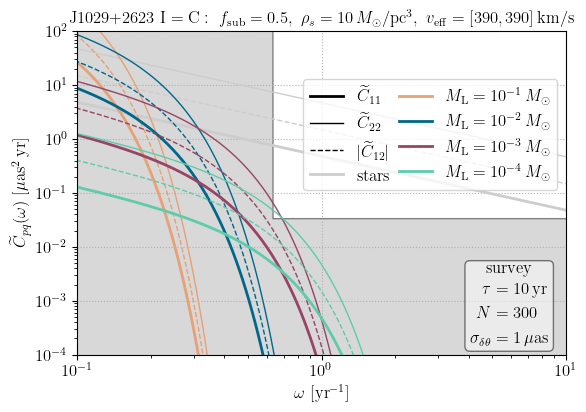

In [27]:
# ---------------------------------------------------------------------------
# Figure 1: stochastic PSD  C_pq(omega)  for the bright image (Eq. C)
# ---------------------------------------------------------------------------
vec_omega = np.logspace(-1.3, 1.3, 400) * year**-1
vec_M_L = np.asarray([1e-1, 1e-2, 1e-3, 1e-4]) * M_Solar
rho_s = 1e1 * M_Solar * pc**-3

arr_C_ij_DM = np.zeros((3, len(vec_M_L), 2, 2, len(vec_omega)))
for j, M_L in enumerate(vec_M_L):
    r_L = (M_L/(rho_s*(4*np.pi*np.exp(1/2))))**(1/3)
    gamma_L = r_L/d_lens
    theta_E_L = theta_E(M_L, d_lens, d_source, d_lens_source)
    for i in range(3):
        x_k = gamma_L/mu_tilde[i] * vec_omega
        x_src = theta_src_I[i]/mu_tilde[i] * vec_omega   # optical finite-source cutoff
        arr_C_ij_DM[i, j] = kappa_L[i] * theta_E_L**2 / vec_omega * C_ij_integral_src(x_k, x_src, zeta[i])
arr_C_pq_DM = np.einsum('aqj,abpjm->abpqm', inv_jacobian_fit,
                       np.einsum('api,abijm->abpjm', inv_jacobian_fit, arr_C_ij_DM))

# Naive stellar PSD (point lenses at kappa_* = 0.003) and the white instrumental floor of
# Eq. (noise_1). The stars are far rarer here than in the galaxy lens: single identifiable
# perturbers rather than a stochastic background (Sec. III D).
vec_C_star = kappa_star * theta_E_star**2 / vec_omega * np.pi
arr_C_ij_star = np.asarray([[vec_C_star, np.zeros_like(vec_C_star)], [np.zeros_like(vec_C_star), vec_C_star]])
arr_C_pq_star = np.einsum('aqj,apjm->apqm', inv_jacobian_fit, np.einsum('api,ijm->apjm', inv_jacobian_fit, arr_C_ij_star))
vec_C_inst = C_inst(vec_omega, tau=tau, N_obs=N_obs, sigma_delta_theta=sigma_delta_theta)

idx_I = 2   # bright image C (mu ~ -22)
fig, ax = plt.subplots(1, 1, figsize=(6.3, 4.2))
colors = [sns.color_palette(xgfs_fancy6)[i] for i in [2, 3, 4, 5, 6]]
ax.plot([], [], color='k', lw=2, label=r'$\widetilde{C}_{11}$')
ax.plot([], [], color='k', lw=1, label=r'$\widetilde{C}_{22}$')
ax.plot([], [], color='k', lw=1, ls='dashed', label=r'$|\widetilde{C}_{12}|$')
i = idx_I
ax.plot(vec_omega/year**-1, arr_C_pq_star[i, 0, 0]/(muas**2*year), color=colors[4], lw=2, label='stars')
ax.plot(vec_omega/year**-1, arr_C_pq_star[i, 1, 1]/(muas**2*year), color=colors[4], lw=1)
ax.plot(vec_omega/year**-1, np.abs(arr_C_pq_star[i, 0, 1])/(muas**2*year), color=colors[4], lw=1, ls='dashed')
for j, M_L in enumerate(vec_M_L):
    ax.plot(vec_omega/year**-1, arr_C_pq_DM[i, j, 0, 0]/(muas**2*year), color=colors[j], lw=2,
            label=r'$M_\mathrm{L} = 10^{%.2g} \, M_\odot$' % np.log10(M_L/M_Solar))
    ax.plot(vec_omega/year**-1, arr_C_pq_DM[i, j, 1, 1]/(muas**2*year), color=colors[j], lw=1)
    ax.plot(vec_omega/year**-1, np.abs(arr_C_pq_DM[i, j, 0, 1])/(muas**2*year), color=colors[j], lw=1, ls='dashed')
ax.fill_between(vec_omega/year**-1, vec_C_inst/(muas**2*year), color=(0.5, 0.5, 0.5, 1), facecolor=(0.5, 0.5, 0.5, 0.3), lw=1)
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel(r'$\omega~ [\mathrm{yr}^{-1}$]')
ax.set_ylabel(r'$\widetilde{C}_{pq}(\omega) ~[\mathrm{\mu as^2 \, yr}]$')
ax.grid(ls='dotted'); ax.set_xlim(1e-1, 1e1); ax.set_ylim(1e-4, 1e2)
ax.legend(loc='center right', bbox_to_anchor=(1, 0.68), ncol=2, labelspacing=0.5, columnspacing=0.5)
ax.text(0.85e1, 8e-4,
        r'\begin{align*} \text{survey} \end{align*} \vspace{-3em} \begin{align*}\tau &= %.5g \,\mathrm{yr} \\ N &= %.5g \\ \sigma_{\delta \theta} &= %.5g \, \mathrm{ \mu as} \end{align*}'
        % ((tau/year), (N_obs), (sigma_delta_theta/muas)),
        ha='right', va='center', bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))
ax.set_title(r'$\mathrm{J1029{+}2623}~\text{I}=\mathrm{%s}: ~f_\mathrm{sub} = %.1g, ~\rho_s = %.2g \,M_\odot/\mathrm{pc^3}, ~v_\mathrm{eff} = [%.3g,%.3g] \,\mathrm{km/s}$'
             % (labels[idx_I], f_sub, (rho_s/(M_Solar/pc**3)), (v_lens[0]/(km/second)), (v_lens[1]/(km/second))),
             fontsize=12)
fig.savefig('../figs/CtildeC-J1029.pdf', bbox_inches='tight')
print("saved ../figs/CtildeC-J1029.pdf")
plt.show()

## Differential acceleration covariance vs $M_\mathrm{L}$  →  `figs/acc-J1029.pdf`

Direct analogue of the galaxy-lens `figs/acc.pdf` above (Part I). The computation lives in the next cell and the plotting (labels, ranges) in the one after it, so the figure can be re-tuned without recomputing.

In [28]:
# ---------------------------------------------------------------------------
# differential acceleration covariance vs M_L (Eq. observable_2) -- COMPUTATION
# ---------------------------------------------------------------------------
def smear_F2(a):
    return np.heaviside(-a + 1e-2, 0) + np.heaviside(a - 1e-2, 0) * 14400 * (6*a*np.cos(a/2) + (-12 + a**2)*np.sin(a/2))**2 / a**10

list_r_L = 10**np.arange(-4.5, 1.5, 0.04) * pc
vec_omega_wide = np.logspace(-6, 2, int(5e2)) * 2*np.pi/tau
d_omega_wide = vec_omega_wide[1:] - vec_omega_wide[:-1]
vec_F2 = smear_F2(vec_omega_wide[1:]*tau)

def acc_cov_pairs(rho_s_val, theta_src_I=np.zeros(3)):
    '''Largest-eigenvalue differential acceleration covariance, Eq. (observable_2), for
    the three image pairs, along the r_L grid at fixed rho_s.

    NB kappa_L already carries f_sub (kappa_L = f_sub*kappa_fit), so f_sub must not be
    applied again here.
    theta_src_I : per-image magnified source size theta_src^I (0 = point source), which
    enters the form factor in quadrature with the halo size via C_ij_integral_src.
    The factor 2 in the omega sum counts the negative frequencies of the two-sided PSD.
    '''
    list_M_L = 4*np.pi*np.exp(0.5)*rho_s_val*list_r_L**3
    list_gamma_L = list_r_L/d_lens
    list_theta_E_L = theta_E(list_M_L, d_lens, d_source, d_lens_source)
    arr_C_ij = np.zeros((3, len(list_r_L), 2, 2, len(vec_omega_wide)))
    for i in range(3):
        x_k = list_gamma_L[:, None]/mu_tilde[i]*vec_omega_wide
        x_src = theta_src_I[i]/mu_tilde[i]*vec_omega_wide
        arr_C_ij[i] = kappa_L[i]*list_theta_E_L[:, None, None, None]**2/vec_omega_wide \
            * np.transpose(C_ij_integral_src(x_k, x_src, zeta[i]), axes=(2, 0, 1, 3))
    arr_C_pq = np.einsum('aqj,abpjm->abpqm', inv_jacobian_fit, np.einsum('api,abijm->abpjm', inv_jacobian_fit, arr_C_ij))
    pairs = [(0, 1), (0, 2), (1, 2)]  # AB, AC, BC
    out = np.zeros((len(pairs), len(list_r_L), 2, 2))
    for p, (i, j) in enumerate(pairs):
        dC = arr_C_pq[i] + arr_C_pq[j]      # (r_L, 2, 2, omega)
        out[p] = 2*np.sum(vec_F2*d_omega_wide/(2*np.pi)*vec_omega_wide[1:]**4*dC[:, :, :, 1:], axis=-1)
    eig = np.max(np.linalg.eigvals(np.transpose(out, (0, 1, 2, 3))), axis=-1)
    M_L = list_M_L
    return M_L, np.real(eig)   # (pair, r_L)

# Consolidated acceleration figure: the OPTICAL differential-acceleration covariance
# vs M_L, at the two CDM-plausible scale densities rho_s = 1, 10 M_sun/pc^3.
M_L_1, acc_1 = acc_cov_pairs(1.0*M_Solar/pc**3, theta_src_I=theta_src_I)
M_L_10, acc_10 = acc_cov_pairs(10.0*M_Solar/pc**3, theta_src_I=theta_src_I)
sigma_theta_ddot = np.sqrt(720 * sigma_delta_theta**2 / (tau**4 * N_obs))   # Eq. (noise_2)
pAB, pAC, pBC = 0, 1, 2

print("\ndetection headroom (optical, sigma_delta_theta=%.2g muas; floor = %.2e (muas/yr^2)^2):"
      % (sigma_delta_theta/muas, sigma_theta_ddot**2/muasyy**2))
for rho, (Ml, acc) in [(1, (M_L_1, acc_1)), (10, (M_L_10, acc_10))]:
    for p, nm in [(pAB, 'A,B'), (pAC, 'A,C'), (pBC, 'B,C')]:
        pk = acc[p].max(); Mpk = Ml[np.argmax(acc[p])]
        det = Ml[acc[p] > sigma_theta_ddot**2]/M_Solar
        rng = "%.1e--%.1e" % (det[0], det[-1]) if det.size else "none"
        print("  rho_s=%2d %s: peak=%.2e at M_L=%.2g, SNR^2_peak=%4.1f, detect M_L=%s M_sun"
              % (rho, nm, pk/muasyy**2, Mpk/M_Solar, pk/sigma_theta_ddot**2, rng))


detection headroom (optical, sigma_delta_theta=1 muas; floor = 2.40e-04 (muas/yr^2)^2):
  rho_s= 1 A,B: peak=1.66e-04 at M_L=0.0005, SNR^2_peak= 0.7, detect M_L=none M_sun
  rho_s= 1 A,C: peak=1.61e-04 at M_L=0.00038, SNR^2_peak= 0.7, detect M_L=none M_sun
  rho_s= 1 B,C: peak=3.26e-04 at M_L=0.0005, SNR^2_peak= 1.4, detect M_L=9.5e-05--3.4e-03 M_sun
  rho_s=10 A,B: peak=1.66e-03 at M_L=0.005, SNR^2_peak= 6.9, detect M_L=6.0e-05--6.6e+00 M_sun
  rho_s=10 A,C: peak=1.61e-03 at M_L=0.0038, SNR^2_peak= 6.7, detect M_L=6.0e-05--6.6e+00 M_sun
  rho_s=10 B,C: peak=3.26e-03 at M_L=0.005, SNR^2_peak=13.6, detect M_L=2.6e-05--6.0e+01 M_sun


median nearest star at 15.7 muas -> worst-case acc^2 = 2.16e-04 (muas/yr^2)^2


saved ../figs/acc-J1029.pdf
sigma_theta_ddot(survey, optical) = 0.015 muas/yr^2


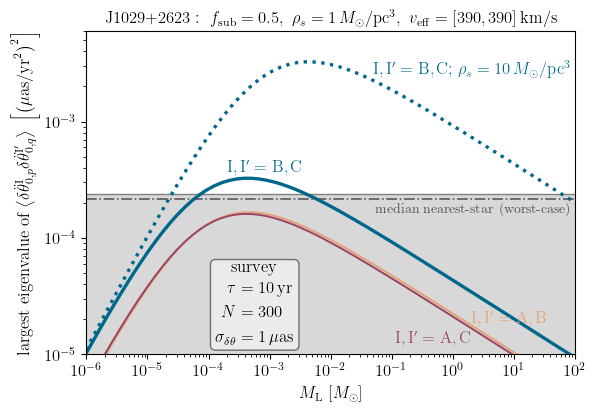

In [29]:
# ---------------------------------------------------------------------------
# differential acceleration covariance vs M_L -- PLOT (labels/ranges tuned)
# ---------------------------------------------------------------------------
# All label positions are given directly in data coordinates (M_L in M_sun,
# covariance in (muas/yr^2)^2) so they are easy to nudge interactively.
fig, ax = plt.subplots(1, 1, figsize=(6.3, 4.2))
colors = sns.color_palette(xgfs_fancy6)

# --- noise floor (survey) + worst-case identifiable single-star acceleration ---
ax.fill_between(M_L_1/M_Solar, sigma_theta_ddot**2/muasyy**2,
                color=(0.5, 0.5, 0.5, 1), facecolor=(0.5, 0.5, 0.5, 0.3))
# worst-case acceleration from the median nearest star (Sec. III D): a single,
# identifiable, few-parameter perturber -- half of all images are cleaner than
# this for the entire campaign, and the trend can be jointly fit and removed.
n_star_dens = kappa_star * Sigma_crit_val / M_star
theta_near_med = np.sqrt(np.log(2)/(np.pi*n_star_dens)) / d_lens
B_max_C = np.max(np.abs(eigvals_fit[2]))
acc_star_wc = 2*B_max_C*theta_E_star**2*mu_tilde[2]**2/theta_near_med**3
print("median nearest star at %.1f muas -> worst-case acc^2 = %.2e (muas/yr^2)^2"
      % (theta_near_med/muas, acc_star_wc**2/muasyy**2))
ax.axhline(acc_star_wc**2/muasyy**2, color=(0.35, 0.35, 0.35), lw=1.2, ls='dashdot')

# --- signal curves ---
# rho_s = 1 M_sun/pc^3 (solid): the three image pairs; B,C is the bright pair
ax.plot(M_L_1/M_Solar, acc_1[pAB]/muasyy**2, color=colors[2], lw=1.4)
ax.plot(M_L_1/M_Solar, acc_1[pAC]/muasyy**2, color=colors[4], lw=1.4)
ax.plot(M_L_1/M_Solar, acc_1[pBC]/muasyy**2, color=colors[3], lw=2.4)
# rho_s = 10 M_sun/pc^3 (dotted): the bright B,C pair -> strongest detection prospect
ax.plot(M_L_10/M_Solar, acc_10[pBC]/muasyy**2, color=colors[3], lw=2.4, ls='dotted')

ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlim(1e-6, 1e2)
ax.set_ylim(1e-5, 6e-3)      # tightened range: bottom just below the curve tails
                             # (~5e-6), top just above the rho_s=10 dotted peak (3.3e-3)
ax.set_xlabel(r'$M_\mathrm{L}~[M_\odot]$')
ax.set_ylabel(r'largest eigenvalue of $\big \langle \delta \ddot \theta^\mathrm{I}_{0,p} \delta \ddot \theta^\mathrm{I^\prime}_{0,q} \big \rangle~\left[\left(\mathrm{\mu as / yr}^2\right)^2\right]$')

# --- curve labels (data coords; nudge freely) --------------------------------
# B,C  rho_s=10 (dotted): above the descending branch, clear upper-right band
ax.text(5e-2, 2.4e-3, r'$\mathrm{I,I^\prime = B,C}$; '+r'$\rho_s = 10\,M_\odot / \mathrm{pc}^3$',
        color=colors[3], ha='left', va='bottom')
# B,C  rho_s=1 (solid): floating in the gap between the solid B,C and dotted curves
ax.text(2e-4, 4.0e-4, r'$\mathrm{I,I^\prime = B,C}$', color=colors[3], ha='left', va='center')
# A,C: below the (near-degenerate) A,B/A,C track on the rising left branch
ax.text(2, 1.6e-5, r'$\mathrm{I,I^\prime = A,C}$', color=colors[4], ha='right', va='top')
# A,B: below the same track on the descending right branch (far from A,C)
ax.text(2, 1.75e-5, r'$\mathrm{I,I^\prime = A,B}$', color=colors[2], ha='left', va='bottom')

# --- survey box (upper-left corner) ---
#ax.text(1.3e-6, 5.3e-3,
ax.text(1.3e-4, 1.2e-5,
        r'\begin{align*} \text{survey} \end{align*} \vspace{-3em} \begin{align*}\tau &= %.5g \,\mathrm{yr} \\ N &= %.5g \\ \sigma_{\delta \theta} &= %.5g \, \mathrm{ \mu as} \end{align*}'
        % ((tau/year), (N_obs), (sigma_delta_theta/muas)),
        ha='left', va='bottom', bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))

# --- horizontal-line labels (anchored at opposite ends so they never collide) ---
#ax.text(1e-1, 2.5e-4, r'noise floor', fontsize=8.5, ha='left', va='bottom', color=(0.3, 0.3, 0.3))
ax.text(9e1, 2.0e-4, r'median nearest-star (worst-case)',
        fontsize=10, color=(0.3, 0.3, 0.3), ha='right', va='top')

ax.set_title(r'$\mathrm{J1029{+}2623}: ~f_\mathrm{sub} = %.1g, ~\rho_s = 1\,M_\odot/\mathrm{pc^3}, ~v_\mathrm{eff} = [%.3g,%.3g] \,\mathrm{km/s}$'
             % (f_sub, (v_lens[0]/(km/second)), (v_lens[1]/(km/second))), fontsize=12)
fig.savefig('../figs/acc-J1029.pdf', bbox_inches='tight')
print("saved ../figs/acc-J1029.pdf")
print("sigma_theta_ddot(survey, optical) = %.2g muas/yr^2" % (sigma_theta_ddot/muasyy))
plt.show()

## Finite-source + VLBI-radio study (printed diagnostics only)

The radio channel does not clear its noise floor for fiducial VLBI precision, so it
is reported here (feeding the numbers quoted in the text) but omitted from the
consolidated figure.

In [30]:
# ---------------------------------------------------------------------------
# Finite-source + VLBI-radio study (printed diagnostics only; no longer plotted).
# ---------------------------------------------------------------------------
rho_acc = 1.0*M_Solar/pc**3
_,  acc_point = acc_cov_pairs(rho_acc, theta_src_I=np.zeros(3))
_,  acc_opt   = acc_cov_pairs(rho_acc, theta_src_I=theta_src_I)
_,  acc_r001  = acc_cov_pairs(rho_acc, theta_src_I=theta_src_radio_I[:, 0])
_,  acc_r01   = acc_cov_pairs(rho_acc, theta_src_I=theta_src_radio_I[:, 1])
M_L_a, acc_r1 = acc_cov_pairs(rho_acc, theta_src_I=theta_src_radio_I[:, 2])

print("\nfinite-source effect on the B,C acceleration peak (rho_s=1):")
for name, acc in [("point ", acc_point), ("optical", acc_opt), ("radio 0.01pc", acc_r001),
                  ("radio 0.1pc ", acc_r01), ("radio 1pc  ", acc_r1)]:
    pk = acc[pBC].max(); Mpk = M_L_a[np.argmax(acc[pBC])]
    print("  %-12s peak = %.2e (muas/yr^2)^2 at M_L = %.2g M_sun" % (name, pk/muasyy**2, Mpk/M_Solar))

sigma_acc_VLBI = np.sqrt(720 * sigma_delta_theta_VLBI**2 / (tau**4 * N_obs))
sigma_acc_VLBI_future = np.sqrt(720 * sigma_delta_theta_VLBI_future**2 / (tau**4 * N_obs))
# VLBI precision required for SNR=1 at the radio (0.01 pc) B,C peak:
peak_r001 = acc_r001[pBC].max()
sigma_delta_theta_req = np.sqrt(peak_r001 * tau**4 * N_obs / 720)
print("radio(0.01pc) B,C peak acc = %.2g (muas/yr^2)^2 at M_L = %.2g M_sun"
      % (peak_r001/muasyy**2, M_L_a[np.argmax(acc_r001[pBC])]/M_Solar))
print("VLBI sigma_delta_theta for SNR=1 (radio 0.01pc, B,C) = %.2g muas" % (sigma_delta_theta_req/muas))
print("surviving mass range vs VLBI(%.0f muas): " % (sigma_delta_theta_VLBI/muas),
      "%.1e--%.1e M_sun" % tuple(M_L_a[acc_r001[pBC] > sigma_acc_VLBI**2][[0, -1]]/M_Solar)
      if np.any(acc_r001[pBC] > sigma_acc_VLBI**2) else "none above noise")
print("radio does not clear its noise floor for fiducial VLBI -> omitted from figure.")


finite-source effect on the B,C acceleration peak (rho_s=1):
  point        peak = 3.90e-04 (muas/yr^2)^2 at M_L = 0.00029 M_sun
  optical      peak = 3.26e-04 (muas/yr^2)^2 at M_L = 0.0005 M_sun
  radio 0.01pc peak = 2.85e-05 (muas/yr^2)^2 at M_L = 0.66 M_sun
  radio 0.1pc  peak = 2.86e-06 (muas/yr^2)^2 at M_L = 6.6e+02 M_sun
  radio 1pc    peak = 2.84e-07 (muas/yr^2)^2 at M_L = 5e+05 M_sun
radio(0.01pc) B,C peak acc = 2.8e-05 (muas/yr^2)^2 at M_L = 0.66 M_sun
VLBI sigma_delta_theta for SNR=1 (radio 0.01pc, B,C) = 0.34 muas
surviving mass range vs VLBI(10 muas):  none above noise
radio does not clear its noise floor for fiducial VLBI -> omitted from figure.
